### PH464/564: Scientific Computing II
___

# Homework 2
### Due: Mon, Oct 13th at 11:59pm Pacific
---

The purpose of this assignment is to get comfortable working with a few of the tools we'll be using throughout the course (e.g., git, jupyter notebooks, pandas, matplotlib), and to do some basic data exploration and statistics.

Data sets (in the `data` directory):

[US Births 2000-2014](https://raw.githubusercontent.com/fivethirtyeight/data/master/births/US_births_2000-2014_SSA.csv)

[TMDB Movie Dataset](https://www.kaggle.com/tmdb/tmdb-movie-metadata/data)

NOTE: The TMDB data is hosted on kaggle.  See the host page for details on the data. There are two separate data sets from TMDB, one for movie details and one for credits.  These files include some data in JSON format; see [here](https://www.kaggle.com/sohier/getting-imdb-kernels-working-with-tmdb-data/) for tips on reading the data.


1. Find an interesting feature in the US Birth data set that we didn't find in class.  Be sure to describe clearly the feature you found, and include figures to back it up.

2. In class we found that the total number of births roughly correlated with the rise of the housing bubble and subsequent great recession.  We also found that people were generally superstitious, having fewer babies on Friday the 13th compared to other weekdays.  Does the level of superstition change with the health of the US economy?
**564 students**: find some actual public data on the health of the US economy and see if a particular metric tracks with the annual birth rate in the US.

3. Download and parse the TMDB data.  Find an interesting feature in the data.  Be sure to describe clearly the feature you found, and include figures to back it up.

## Problem 1

#### Concepts Covered in the Example Notebook
- births by year
- births by date month
- births by day of the month
- births by day of the month sans holidays
- births on the 13 relative to births not on the 13th
- births on friday vs any day

#### Current ideas I have:
- birth rates ~39-40 weeks after US holidays
- birth rates around tax season
- birth rates for weekdays vs weekends over the years (increase in scheduled births?)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

In [2]:
matplotlib.rcParams['font.family'] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"
font = {'size' : 12}
plt.rc('font', **font)

In [3]:
df = pd.read_csv('../data/US_births_2000-2014_SSA.csv')

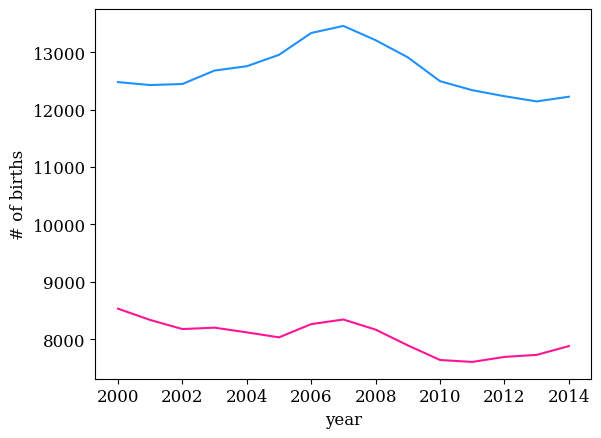

In [5]:
weekday_grp = df[df['day_of_week'].isin([1,2,3,4,5])] #chatgpt told me about isin function for pandas
weekday_mean = weekday_grp.groupby('year')['births'].mean()

weekend_grp = df[df['day_of_week'].isin([6, 7])]
weekend_mean = weekend_grp.groupby('year')['births'].mean()
                 
plt.plot(weekday_mean.index, weekday_mean.values, color='dodgerblue')
plt.plot(weekend_mean.index, weekend_mean.values, color='deeppink')
plt.xlabel('year')
plt.ylabel('# of births');

plt.show()

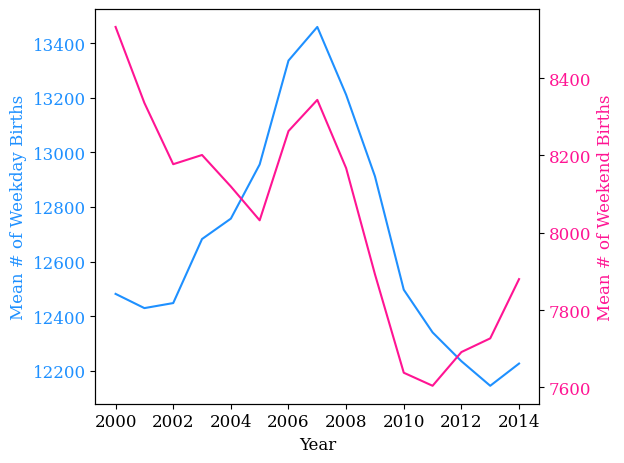

In [5]:
fig, ax1 = plt.subplots() #following matplotlib documentation for doing a plot with 2 y-scales

color = 'dodgerblue'
ax1.plot(weekday_mean.index, weekday_mean.values, color=color)

ax1.set_xlabel('Year')
ax1.set_ylabel('Mean # of Weekday Births', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()

color = 'deeppink'
ax2.plot(weekend_mean.index, weekend_mean.values, color=color)

ax2.set_ylabel('Mean # of Weekend Births', color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.show()

plt.show()

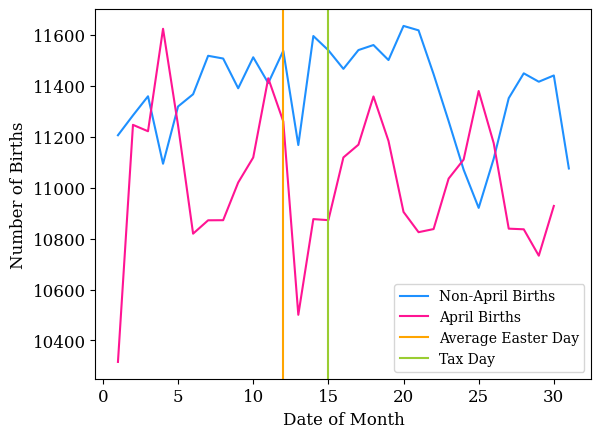

In [11]:
month_sel = df[df['month'] == 4] # leaving this in even though I won't be covering it in the summary
births_by_date_april = month_sel.groupby('date_of_month')['births'].mean()

other_months = df[df['month'] != 4]
births_by_date_other = other_months.groupby('date_of_month')['births'].mean()

plt.plot(births_by_date_other.index, births_by_date_other.values, color='dodgerblue', label='Non-April Births')
plt.plot(births_by_date_april.index, births_by_date_april.values, color='deeppink', label='April Births')

plt.axvline(x=12, color='orange', label=f"Average Easter Day")
plt.axvline(x=15, color='yellowgreen', label=f"Tax Day")
plt.xlabel('Date of Month')
plt.ylabel('Number of Births');
plt.legend(fontsize='small')

plt.show()

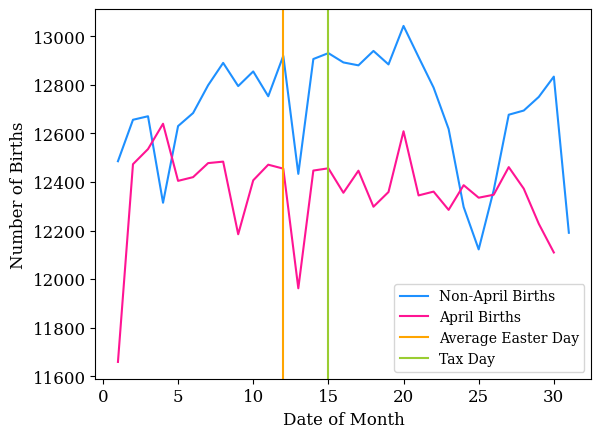

In [12]:
month_sel = month_sel[month_sel['day_of_week'] != 6] # leaving this in even though I won't be covering it in the summary
month_sel = month_sel[month_sel['day_of_week'] != 7]
births_by_date_april = month_sel.groupby('date_of_month')['births'].mean()

other_months = other_months[other_months['day_of_week'] != 6]
other_months = other_months[other_months['day_of_week'] != 7]
births_by_date_other = other_months.groupby('date_of_month')['births'].mean()

plt.plot(births_by_date_other.index, births_by_date_other.values, color='dodgerblue', label='Non-April Births')
plt.plot(births_by_date_april.index, births_by_date_april.values, color='deeppink', label='April Births')

plt.axvline(x=12, color='orange', label=f"Average Easter Day")
plt.axvline(x=15, color='yellowgreen', label=f"Tax Day")
plt.xlabel('Date of Month')
plt.ylabel('Number of Births');
plt.legend(fontsize='small')

plt.show()

## Problem 2

In [14]:
df_jobs = pd.read_csv('./data/unemployment_rate_2000-2014.txt', sep=',', header=0)
df_jobs

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
0,2000,4.0,4.1,4.0,3.8,4.0,4.0,4.0,4.1,3.9,3.9,3.9,3.9
1,2001,4.2,4.2,4.3,4.4,4.3,4.5,4.6,4.9,5.0,5.3,5.5,5.7
2,2002,5.7,5.7,5.7,5.9,5.8,5.8,5.8,5.7,5.7,5.7,5.9,6.0
3,2003,5.8,5.9,5.9,6.0,6.1,6.3,6.2,6.1,6.1,6.0,5.8,5.7
4,2004,5.7,5.6,5.8,5.6,5.6,5.6,5.5,5.4,5.4,5.5,5.4,5.4
5,2005,5.3,5.4,5.2,5.2,5.1,5.0,5.0,4.9,5.0,5.0,5.0,4.9
6,2006,4.7,4.8,4.7,4.7,4.6,4.6,4.7,4.7,4.5,4.4,4.5,4.4
7,2007,4.6,4.5,4.4,4.5,4.4,4.6,4.7,4.6,4.7,4.7,4.7,5.0
8,2008,5.0,4.9,5.1,5.0,5.4,5.6,5.8,6.1,6.1,6.5,6.8,7.3
9,2009,7.8,8.3,8.7,9.0,9.4,9.5,9.5,9.6,9.8,10.0,9.9,9.9


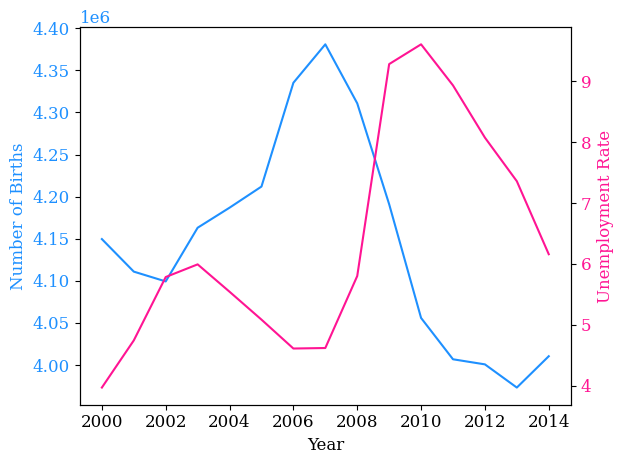

In [16]:
year_grp = df.groupby('year')
births_by_year = year_grp.sum()

jobs_by_year = df_jobs.loc[:, 'Jan':'Dec'].mean(axis=1)

fig, ax1 = plt.subplots() #following matplotlib documentation for doing a plot with 2 y-scales

color = 'dodgerblue'
ax1.plot(births_by_year.index, births_by_year.births, color=color)

ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Births', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()

color = 'deeppink'
ax2.plot(df_jobs.Year, jobs_by_year.values, color=color)

ax2.set_ylabel('Unemployment Rate', color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.show()

## Problem 3

#### Current ideas I have:
- average movie rating over time
- average movie runtime over time
- movie popularity vs average rating
- number of ratings vs average rating
- runtime vs average rating
- rating vs budget

In [19]:
df = pd.read_csv('../../hub_data_share/tmdb_5000_movies.csv')
df

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4798,220000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",NaN,9367,"[{""id"": 5616, ""name"": ""united states\u2013mexi...",es,El Mariachi,El Mariachi just wants to play his guitar and ...,14.269792,"[{""name"": ""Columbia Pictures"", ""id"": 5}]","[{""iso_3166_1"": ""MX"", ""name"": ""Mexico""}, {""iso...",1992-09-04,2040920,81.0,"[{""iso_639_1"": ""es"", ""name"": ""Espa\u00f1ol""}]",Released,"He didn't come looking for trouble, but troubl...",El Mariachi,6.6,238
4799,9000,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 10749, ""...",NaN,72766,[],en,Newlyweds,A newlywed couple's honeymoon is upended by th...,0.642552,[],[],2011-12-26,0,85.0,[],Released,A newlywed couple's honeymoon is upended by th...,Newlyweds,5.9,5
4800,0,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 18, ""nam...",http://www.hallmarkchannel.com/signedsealeddel...,231617,"[{""id"": 248, ""name"": ""date""}, {""id"": 699, ""nam...",en,"Signed, Sealed, Delivered","""Signed, Sealed, Delivered"" introduces a dedic...",1.444476,"[{""name"": ""Front Street Pictures"", ""

In [20]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month
df['release_day'] = df['release_date'].dt.day

In [21]:
df_run = df[df['runtime'] != 0] # drop all 0's
df_vote = df[df['vote_count'] != 0] # drop all movies with 0 votes

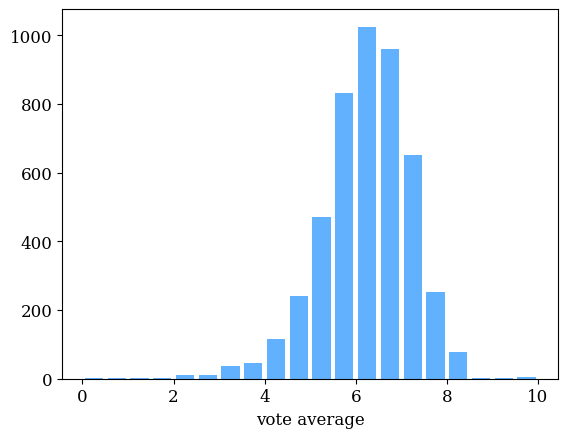

In [12]:
# movie rating distribution
plt.hist(df_vote['vote_average'], bins=20, color='dodgerblue', alpha=0.7, rwidth=0.8)

plt.xlabel('vote average')

plt.show()

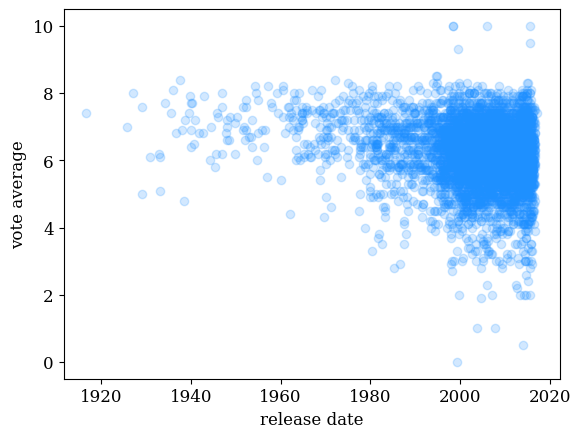

In [13]:
# Average movie rating over time
plt.scatter(df_vote['release_date'], df_vote['vote_average'], color='dodgerblue', alpha=0.2)

plt.xlabel('release date')
plt.ylabel('vote average');

plt.show()

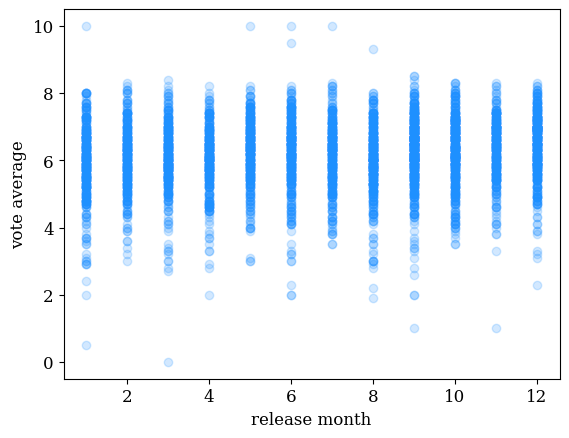

In [14]:
# Average movie rating over time
plt.scatter(df_vote['release_month'], df_vote['vote_average'], color='dodgerblue', alpha=0.2)

plt.xlabel('release month')
plt.ylabel('vote average');

plt.show()

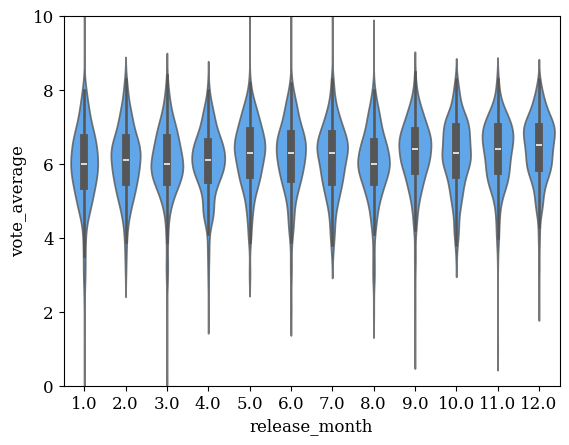

In [66]:
sns.violinplot(x='release_month', y='vote_average', data=df_vote, color='dodgerblue', alpha=0.8);

plt.ylim(0,10)
plt.show()

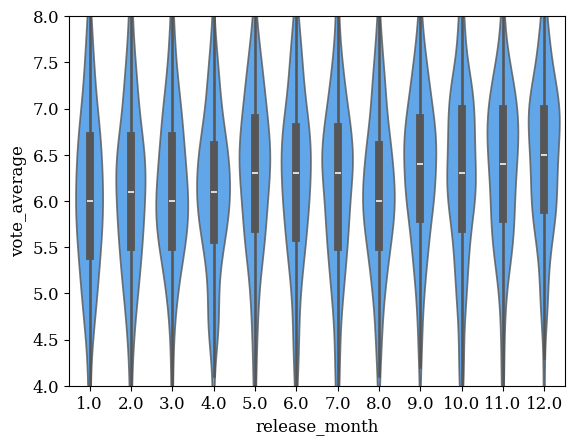

In [25]:
sns.violinplot(x='release_month', y='vote_average', data=df_vote, color='dodgerblue', alpha=0.8);

plt.ylim(4,8)
plt.show()

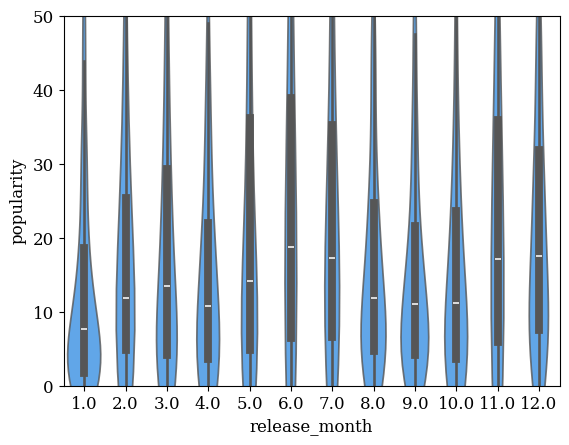

In [26]:
sns.violinplot(x='release_month', y='popularity', data=df, color='dodgerblue', alpha=0.8);

plt.ylim(0,50)
plt.show()

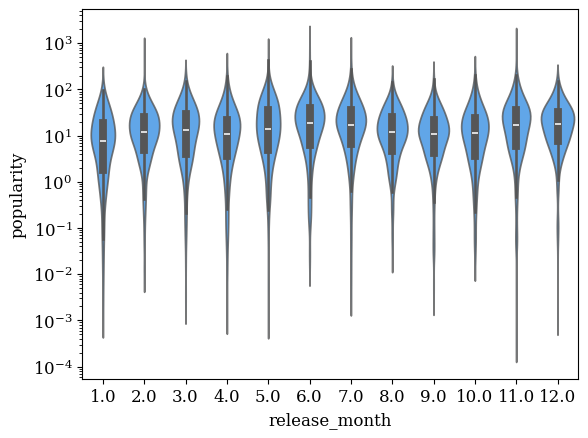

In [55]:
sns.violinplot(x='release_month', y='popularity', data=df, color='dodgerblue', alpha=0.8, log_scale=True);

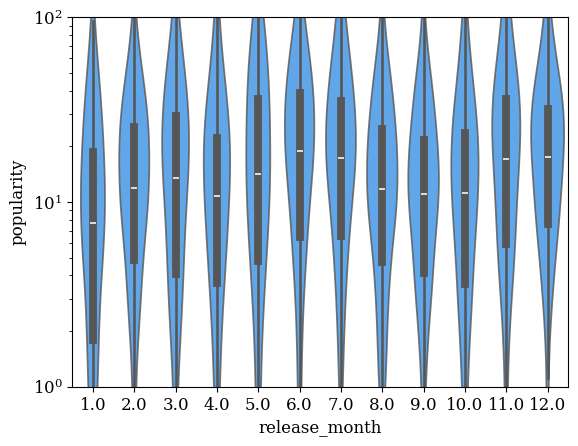

In [27]:
sns.violinplot(x='release_month', y='popularity', data=df, color='dodgerblue', alpha=0.8, log_scale=True);

plt.ylim(1,100)
plt.show()

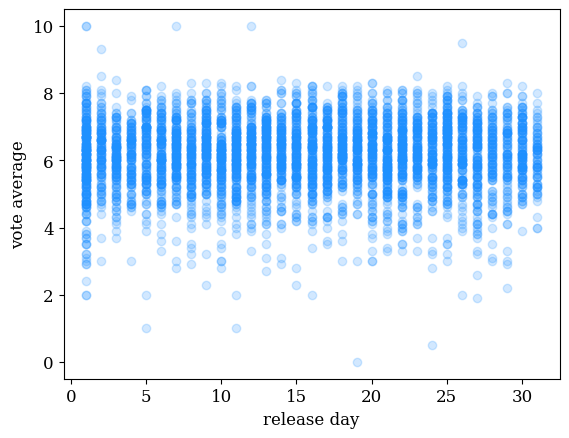

In [16]:
# Average movie rating over time
plt.scatter(df_vote['release_day'], df_vote['vote_average'], color='dodgerblue', alpha=0.2)

plt.xlabel('release day')
plt.ylabel('vote average');

plt.show()

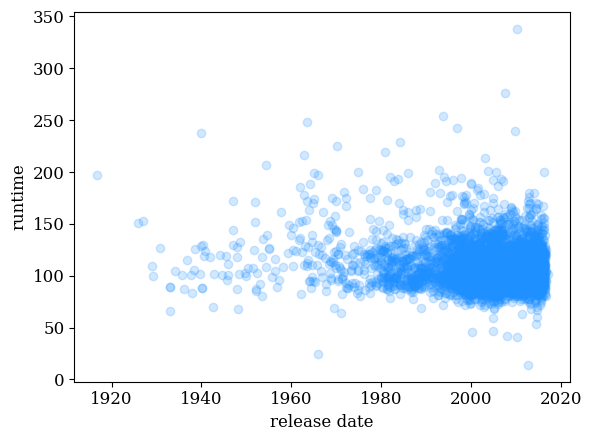

In [17]:
# Average movie runtime over time
plt.scatter(df_run['release_date'], df_run['runtime'], color='dodgerblue', alpha=0.2)

plt.xlabel('release date')
plt.ylabel('runtime');

plt.show()

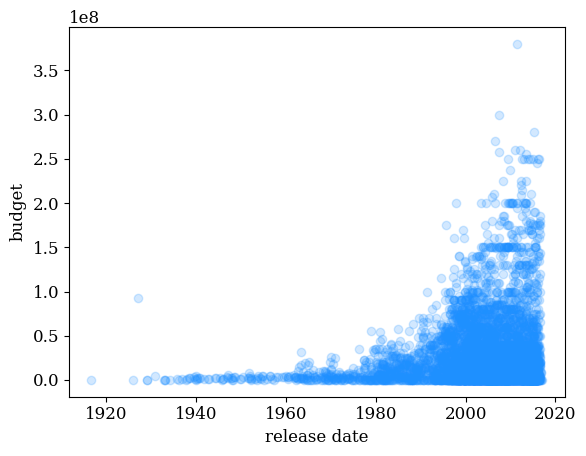

In [18]:
# Average movie runtime over time
plt.scatter(df['release_date'], df['budget'], color='dodgerblue', alpha=0.2)

plt.xlabel('release date')
plt.ylabel('budget');

plt.show()

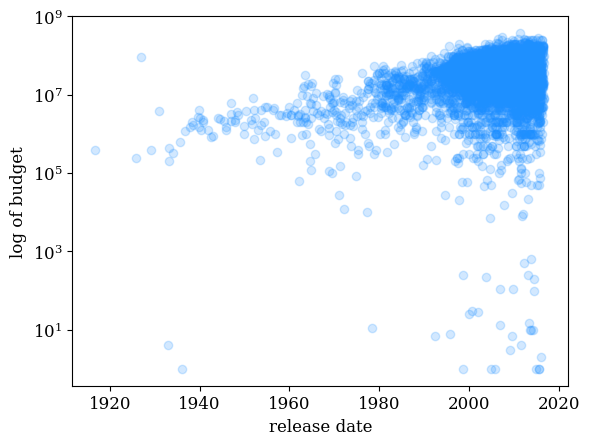

In [28]:
# Average movie runtime over time
plt.scatter(df['release_date'], df['budget'], color='dodgerblue', alpha=0.2)

plt.xlabel('release date')
plt.ylabel('log of budget');
plt.yscale('log')

plt.show()

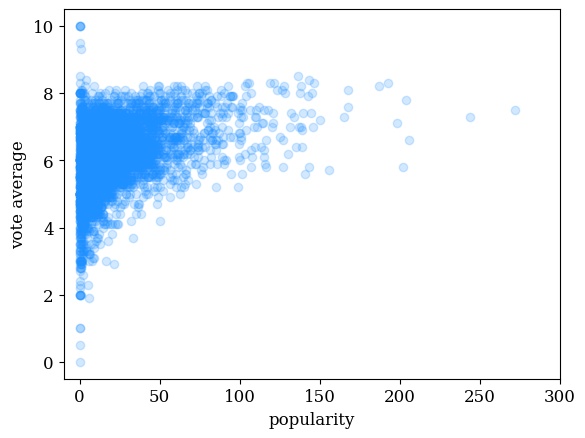

In [20]:
# movie popularity vs vote average
plt.scatter(df_vote['popularity'], df_vote['vote_average'], color='dodgerblue', alpha=0.2)

plt.xlabel('popularity')
plt.ylabel('vote average');

plt.xlim(-10,300)

plt.show()

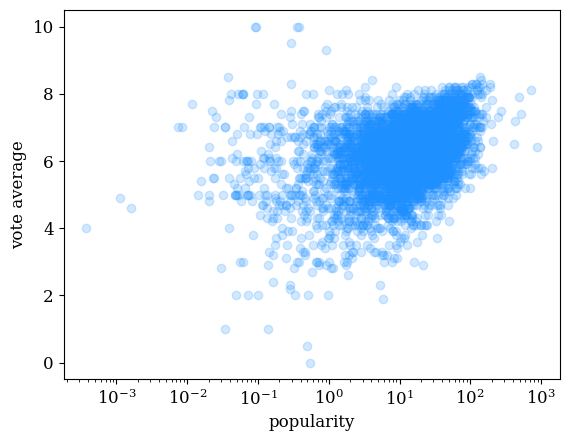

In [49]:
# movie popularity vs vote average
plt.scatter(df_vote['popularity'], df_vote['vote_average'], color='dodgerblue', alpha=0.2)

plt.xlabel('popularity')
plt.ylabel('vote average');
plt.xscale('log')

plt.show()

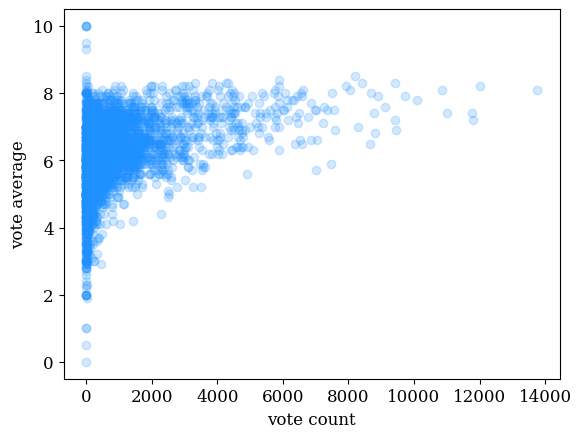

In [22]:
# Average rating vs number of ratings
plt.scatter(df_vote['vote_count'], df_vote['vote_average'], color='dodgerblue', alpha=0.2)

plt.xlabel('vote count')
plt.ylabel('vote average');

plt.show()

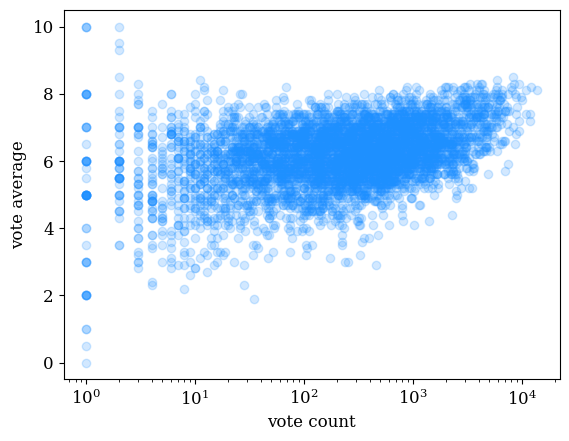

In [30]:
# Average rating vs number of ratings
plt.scatter(df_vote['vote_count'], df_vote['vote_average'], color='dodgerblue', alpha=0.2)

plt.xlabel('vote count')
plt.ylabel('vote average');
plt.xscale('log')

plt.show()

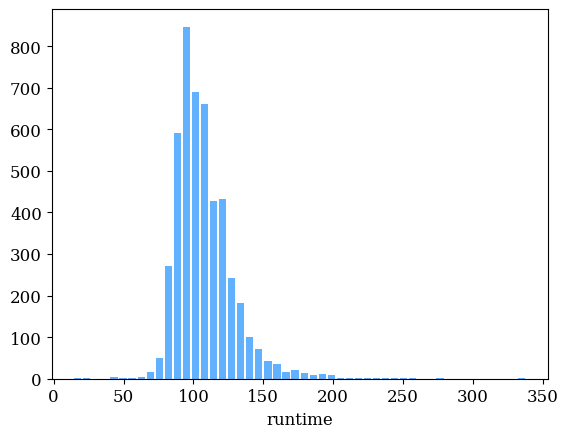

In [23]:
# runtime distribution
plt.hist(df_run['runtime'], bins=50, color='dodgerblue', alpha=0.7, rwidth=0.8)

plt.xlabel('runtime')

plt.show()

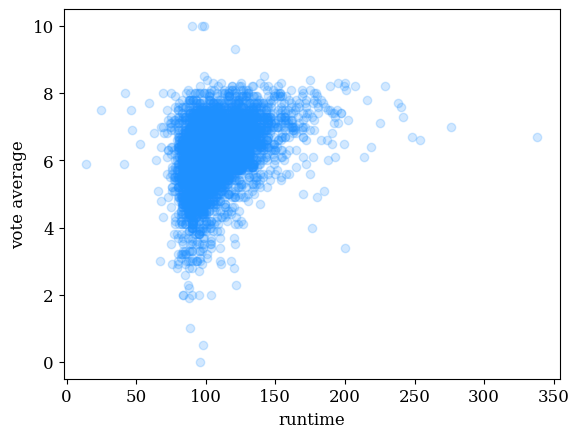

In [24]:
# Average rating vs runtime
df_new = df_run[df_run['vote_count'] != 0]
plt.scatter(df_new['runtime'], df_new['vote_average'], color='dodgerblue', alpha=0.2)

plt.xlabel('runtime')
plt.ylabel('vote average');

plt.show()

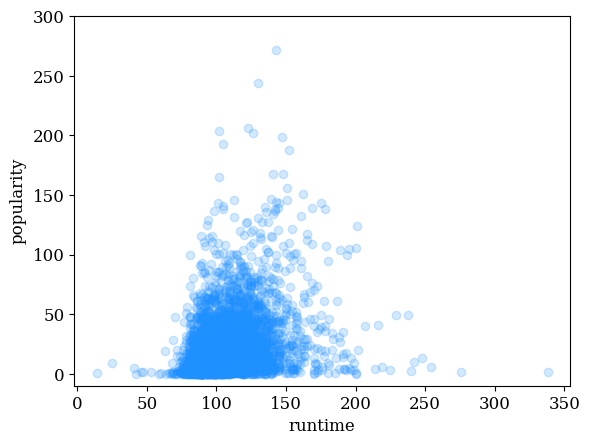

In [25]:
# popularity vs runtime
plt.scatter(df_run['runtime'], df_run['popularity'], color='dodgerblue', alpha=0.2)

plt.xlabel('runtime')
plt.ylabel('popularity');

plt.ylim(-10,300)

plt.show()

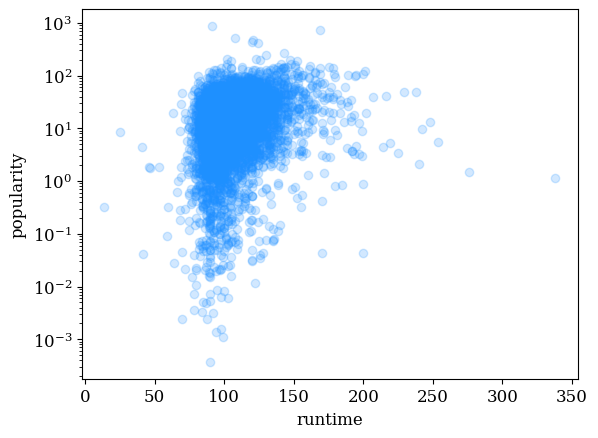

In [47]:
# popularity vs runtime
plt.scatter(df_run['runtime'], df_run['popularity'], color='dodgerblue', alpha=0.2)

plt.xlabel('runtime')
plt.ylabel('popularity');
plt.yscale('log')

plt.show()

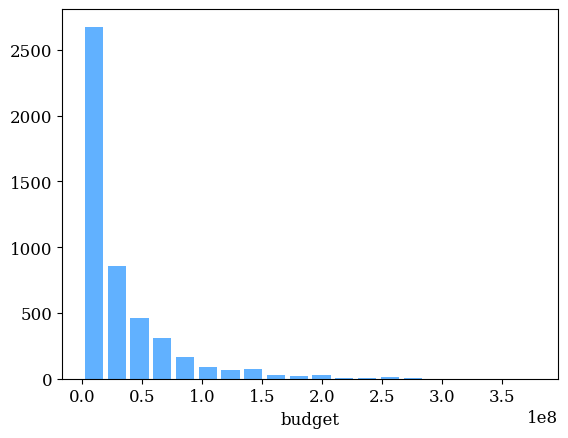

In [27]:
# movie budget distribution
plt.hist(df['budget'], bins=20, color='dodgerblue', alpha=0.7, rwidth=0.8)

plt.xlabel('budget')

plt.show()

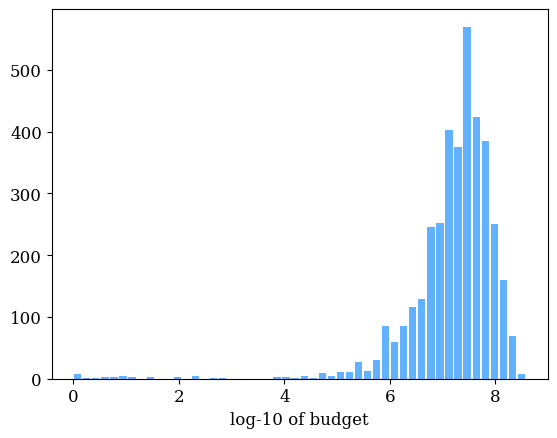

In [28]:
# movie rating distribution
df_new = df[df['budget'] != 0] # drop all 0's since they will make np.log10 mad
plt.hist(np.log10(df_new['budget']), bins=50, color='dodgerblue', alpha=0.7, rwidth=0.8)

plt.xlabel('log-10 of budget')

plt.show()

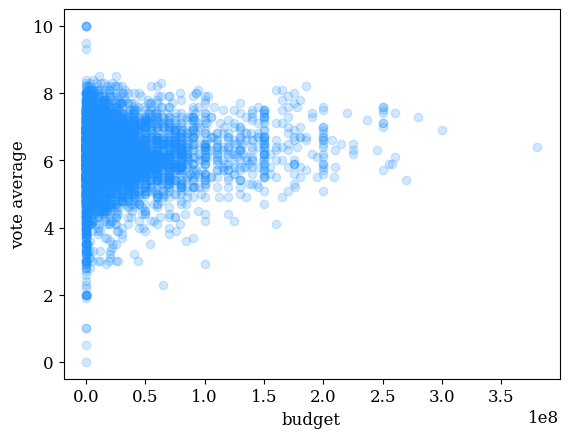

In [29]:
# Average rating vs budget
plt.scatter(df_vote['budget'], df_vote['vote_average'], color='dodgerblue', alpha=0.2)

plt.xlabel('budget')
plt.ylabel('vote average');

plt.show()

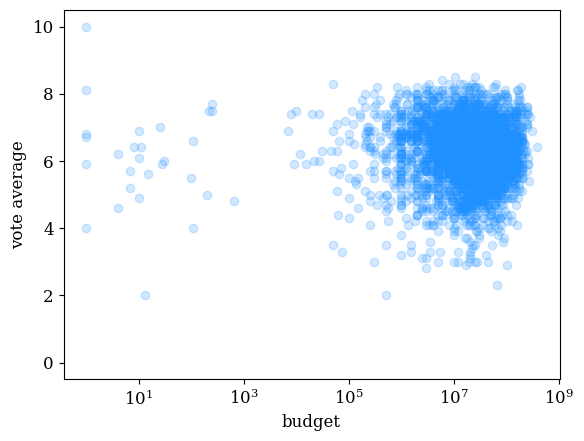

In [50]:
# Average rating vs budget
plt.scatter(df_vote['budget'], df_vote['vote_average'], color='dodgerblue', alpha=0.2)

plt.xlabel('budget')
plt.ylabel('vote average');
plt.xscale('log')

plt.show()

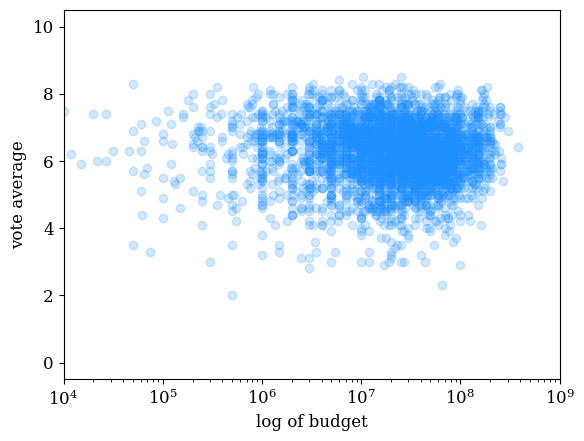

In [29]:
# Average rating vs budget
plt.scatter(df_vote['budget'], df_vote['vote_average'], color='dodgerblue', alpha=0.2)

plt.xlabel('log of budget')
plt.ylabel('vote average');
plt.xscale('log')
plt.xlim(10**4, 10**9)

plt.show()